In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Read the data file

In [32]:
def read_data(file_path):
    df = pd.read_csv(file_path, sep='\t', header=None)
    return df

file_path = 'mapped.bed.gz'
df = read_data(file_path)
print(f"Data loaded: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst few rows of the data:")
display(df.head())

Data loaded: 4336134 rows and 13 columns

First few rows of the data:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90838,91006,IH02_00.pairs@15152,168,+
1,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90846,90998,IH02_04.pairs@4163,152,+
2,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90851,91000,IH02_04.pairs@4164,149,+
3,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90850,91014,IH02_00.pairs@15153,164,+
4,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90900,90965,IH02_00.pairs@15164,65,+


### Step 2: Calculate X, Y, Z values according to the problem statement
    Calculate X, Y, Z values for V-plot:
    X: Difference between centers (C2 - C1)
    Y: Fragment size (Column10 - Column9)
    Z: Counter of Y at X (frequency of each Y value at each X position)

In [33]:
def calculate_xyz(df):
    df['count_1'] = (df[2] + df[3]) / 2 
    df['count_2'] = (df[8] + df[9]) / 2 

    df['X'] = df['count_2'] - df['count_1']
    df['X'] = df['X'].round()
    df['X'] = df['X'].fillna(0).astype(int)

    df['Y'] = df[9] - df[8]

    xy_counts = df.groupby(['X', 'Y']).size().reset_index(name='Z')

    return xy_counts

xyz_data = calculate_xyz(df)

print("\nSample of calculated X, Y, Z values:")
display(xyz_data.head())


Sample of calculated X, Y, Z values:


,X,Y,Z
0,-509,44,7
1,-509,46,10
2,-509,48,7
3,-509,50,21
4,-509,52,17


### Step 3: Create a V-plot heatmap
    Create a V-plot heatmap showing fragment size vs position relative to binding site
    
    Parameters:
    - xyz_data: DataFrame with X, Y, Z columns
    - output_file: If provided, save the plot to this file


Generating V-plot...
Plot saved to v_plot.png


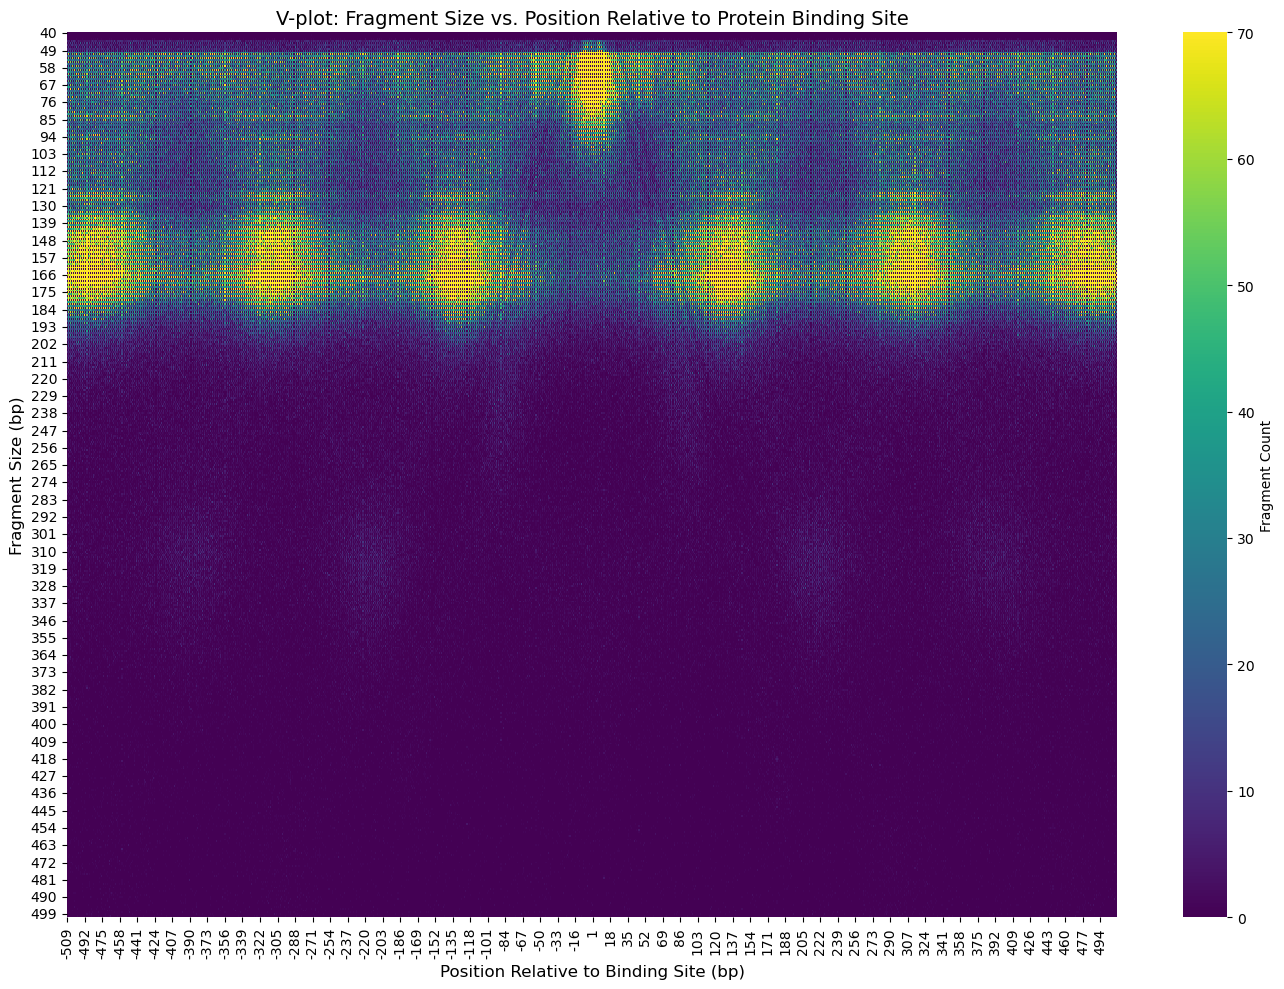

In [34]:
def create_vplot(xyz_data, output_file=None):

    # Convert to a pivot table format suitable for heatmap
    pivot_data = xyz_data.pivot_table(values='Z', index='Y', columns='X', fill_value=0)

    plt.figure(figsize=(14, 10))

    sns.heatmap(pivot_data, cmap='viridis', robust=True)


    plt.xlabel('Position Relative to Binding Site (bp)', fontsize=12)
    plt.ylabel('Fragment Size (bp)', fontsize=12)
    plt.title('V-plot: Fragment Size vs. Position Relative to Protein Binding Site', fontsize=14)


    cbar = plt.gca().collections[0].colorbar
    cbar.set_label('Fragment Count', fontsize=10)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {output_file}")

    return plt

# Create the V-plot
print("\nGenerating V-plot...")
vplot = create_vplot(xyz_data, output_file='v_plot.png')
plt.show()